In [5]:
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt
from collections import Counter

In [6]:
def sample_pa_age(n, m=1, alpha=1, beta=-1, a=1, b=0, c=1, d=1):
    """Generate a preferential attachment network with aging.
    P[i] ~ (c * k_i^alpha + a) * (d * l_i^beta + b)
    where k_i = degree, l_i = age of vertex i.
    """
    g = ig.Graph(n=1, directed=False)
    for t in range(1, n):
        degrees = np.array(g.degree(), dtype=float)
        ages = np.array([t - i for i in range(t)], dtype=float)
        probs = (c * np.power(degrees, alpha) + a) * (d * np.power(ages, beta) + b)
        probs = np.maximum(probs, 0)
        if probs.sum() == 0:
            probs = np.ones(t)
        probs /= probs.sum()
        targets = np.random.choice(t, size=min(m, t), replace=False, p=probs)
        g.add_vertices(1)
        g.add_edges([(t, int(tgt)) for tgt in targets])
    return g

# Demo
np.random.seed(0)
g_age = sample_pa_age(500, m=1, alpha=1, beta=-1, a=1, b=0, c=1, d=1)
print(f"Nodes: {g_age.vcount()} | Edges: {g_age.ecount()}")

Nodes: 500 | Edges: 499


In [7]:
def create_transition_matrix(g):
    """Build a row-stochastic transition matrix. Isolated nodes get a self-loop."""
    adj = np.array(g.get_adjacency().data, dtype=float)
    row_sums = adj.sum(axis=1)
    # Handle isolated nodes by adding self-loops
    isolated = np.where(row_sums == 0)[0]
    adj[isolated, isolated] = 1.0
    row_sums = adj.sum(axis=1)
    return adj / row_sums[:, np.newaxis]

In [8]:
def random_walk(g, num_steps, start_node, transition_matrix=None,
                teleport_prob=0.0, teleport_weights=None, track_path=False):
    """
    Random walk on a graph.
      teleport_prob:    probability of teleporting at each step (0 = no teleportation)
      teleport_weights: array of teleportation target probabilities (None = uniform)
      track_path:       if True, return full path; otherwise return final node
    """
    if transition_matrix is None:
        transition_matrix = create_transition_matrix(g)

    n = g.vcount()
    nodes = np.arange(n)
    v = start_node
    path = [v] if track_path else None

    for _ in range(num_steps):
        if teleport_prob > 0 and np.random.random() < teleport_prob:
            if teleport_weights is None:
                v = np.random.randint(n)
            else:
                v = int(np.random.choice(nodes, p=teleport_weights))
        else:
            v = int(np.random.choice(nodes, p=transition_matrix[v]))
        if track_path:
            path.append(v)

    if track_path:
        return path
    return v

In [9]:
def create_merged_pa_network(n, m):
    """Create a directed PA network with shuffled edges from a second PA network merged in."""
    g1 = ig.Graph.Barabasi(n=n, m=m, directed=True)
    g2 = ig.Graph.Barabasi(n=n, m=m, directed=True)

    # Get edge list of second network and shuffle node indices
    el2 = g2.get_edgelist()
    perm = np.random.permutation(n)
    el2_shuffled = [(int(perm[s]), int(perm[t])) for s, t in el2]

    g1.add_edges(el2_shuffled)
    return g1

# Demo
np.random.seed(0)
g_pr = create_merged_pa_network(900, 4)
print(f"Nodes: {g_pr.vcount()} | Edges: {g_pr.ecount()}")

Nodes: 900 | Edges: 7180


In [10]:
print(sample_pa_age)
print(create_transition_matrix)
print(random_walk)
print(create_merged_pa_network)

<function sample_pa_age at 0x000001B63EC0A3B0>
<function create_transition_matrix at 0x000001B641513F40>
<function random_walk at 0x000001B63EC0A200>
<function create_merged_pa_network at 0x000001B64156C310>


### Transition Matrix for an Undirected Network


8 x 8 sparse Matrix of class "dgCMatrix"
                                                                  
[1,] .    1.0000000 .         .         . .         .    .        
[2,] 0.25 .         0.2500000 0.2500000 . 0.2500000 .    .        
[3,] .    0.5000000 .         .         . .         .    0.5000000
[4,] .    0.2500000 .         .         . 0.2500000 0.25 0.2500000
[5,] .    .         .         .         1 .         .    .        
[6,] .    0.3333333 .         0.3333333 . .         .    0.3333333
[7,] .    .         .         1.0000000 . .         .    .        
[8,] .    .         0.3333333 0.3333333 . 0.3333333 .    .        


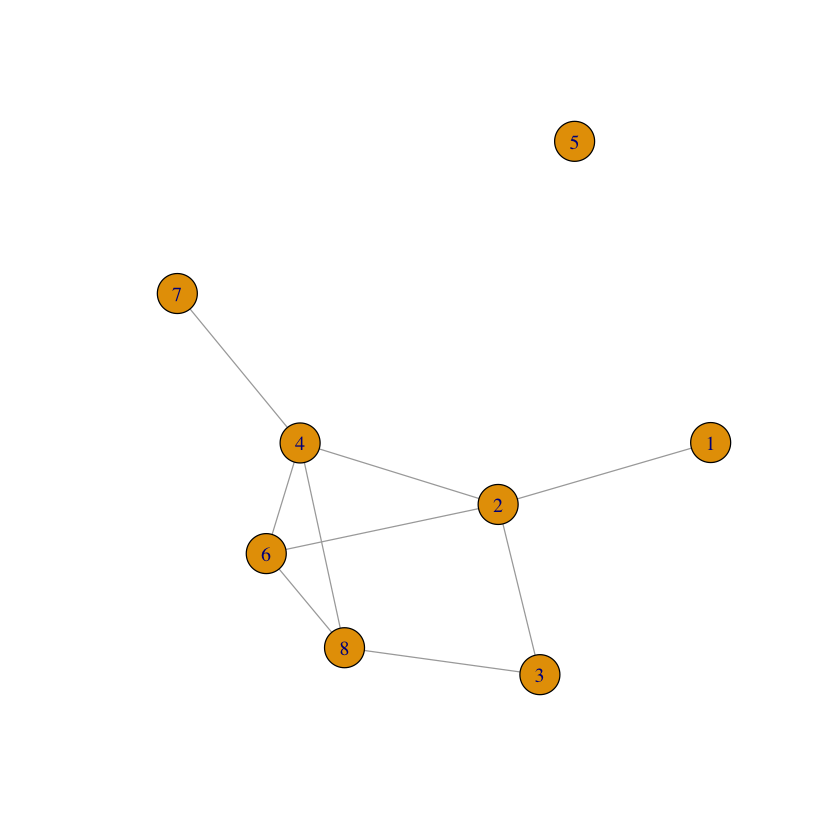

In [33]:
set.seed(0)
g = random.graph.game(8, 0.3)
plot(g)
print(create_transition_matrix(g))

### Transition Matrix for a Directed Network

8 x 8 sparse Matrix of class "dgCMatrix"
                                                                    
[1,] .    .         .    0.5000000 0.5000000 .         .         .  
[2,] 0.20 .         .    .         0.2000000 0.2000000 0.2000000 0.2
[3,] .    0.3333333 .    0.3333333 .         0.3333333 .         .  
[4,] 0.25 .         0.25 .         0.2500000 .         0.2500000 .  
[5,] .    0.5000000 .    .         .         .         .         0.5
[6,] .    0.3333333 .    .         0.3333333 .         0.3333333 .  
[7,] .    .         .    .         .         .         1.0000000 .  
[8,] .    0.2500000 0.25 .         0.2500000 .         0.2500000 .  


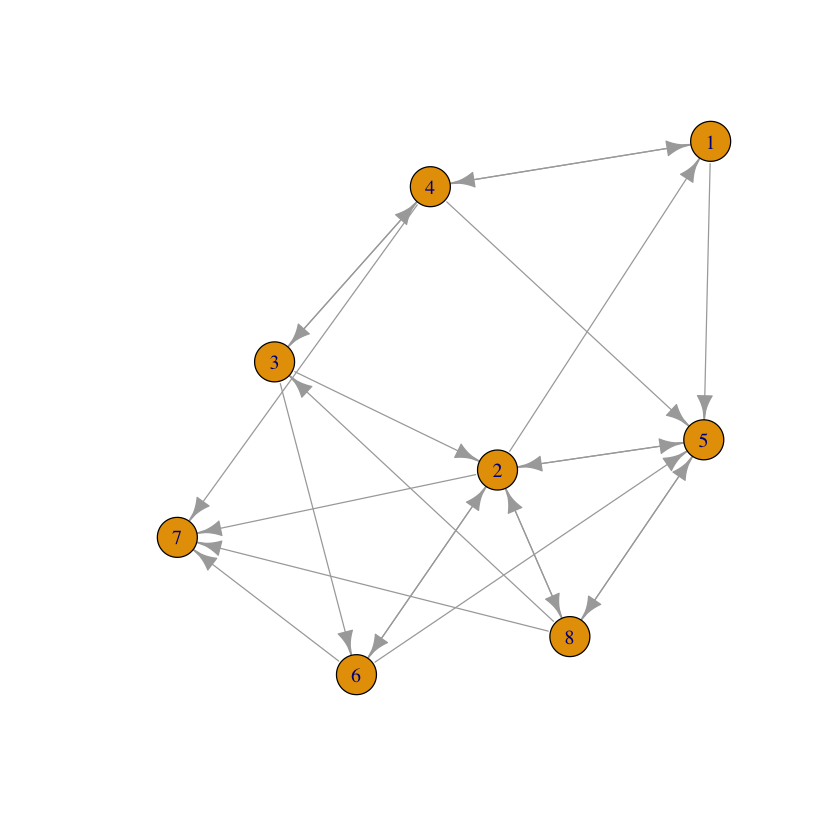

In [34]:
set.seed(1)
g = random.graph.game(8, 0.4, directed = T)
plot(g)
print(create_transition_matrix(g))

In [35]:
random_walk = function (g, num_steps, start_node, transition_matrix = NULL){
    if(is.null(transition_matrix))
        transition_matrix = create_transition_matrix(g)
        
    v = start_node
    for(i in 1:num_steps){
        fprintf('Step %d: %d\n', i, v)  # COMMENT THIS
        PMF = transition_matrix[v, ]
        v = sample(1:vcount(g), 1, prob = PMF)        
    }
    
    return(v)
}

In [37]:
set.seed(1)
v_last = random_walk(g, 15, 1)

Step 1: 1
Step 2: 5
Step 3: 8
Step 4: 2
Step 5: 6
Step 6: 7
Step 7: 7
Step 8: 7
Step 9: 7
Step 10: 7
Step 11: 7
Step 12: 7
Step 13: 7
Step 14: 7
Step 15: 7


1.3 a

In [13]:
np.random.seed(0)

g_age = sample_pa_age(
    n=1050,
    m=1,
    alpha=1,
    beta=-1,
    a=1,
    b=0,
    c=1,
    d=1
)

print("Nodes:", g_age.vcount())
print("Edges:", g_age.ecount())

Nodes: 1050
Edges: 1049


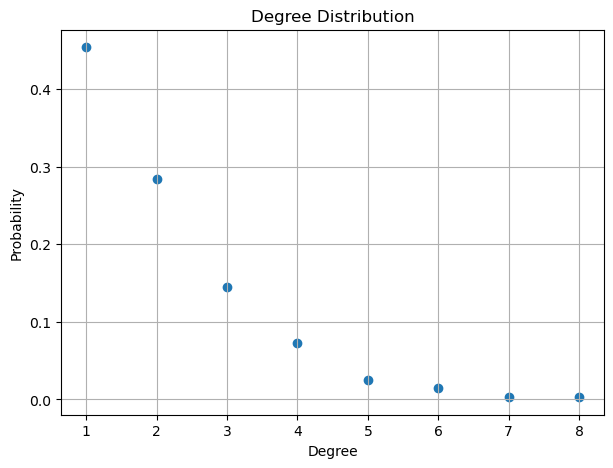

In [14]:
deg = np.array(g_age.degree())
values, counts = np.unique(deg, return_counts=True)
probs = counts / counts.sum()

plt.figure(figsize=(7,5))
plt.scatter(values, probs)
plt.xlabel("Degree")
plt.ylabel("Probability")
plt.title("Degree Distribution")
plt.grid(True)
plt.show()

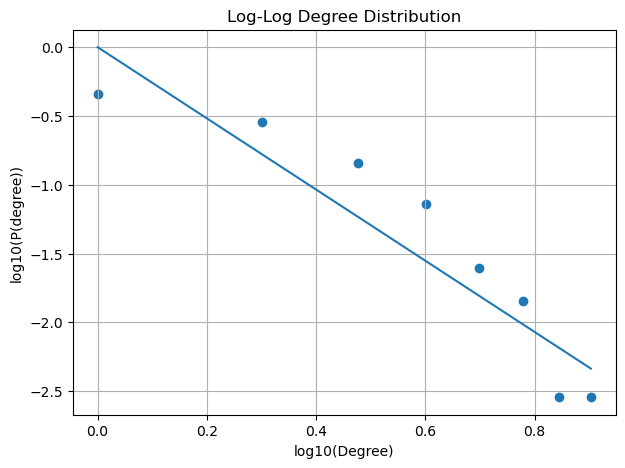

Estimated power-law exponent: 2.5867364271903237


In [15]:
mask = values > 0
x = np.log10(values[mask])
y = np.log10(probs[mask])

slope, _ = np.polyfit(x, y, 1)

plt.figure(figsize=(7,5))
plt.scatter(x, y)
plt.plot(x, slope * x)
plt.xlabel("log10(Degree)")
plt.ylabel("log10(P(degree))")
plt.title("Log-Log Degree Distribution")
plt.grid(True)
plt.show()

print("Estimated power-law exponent:", -slope)

The degree distribution shows heavy-tailed behavior. The log-log plot is approximately linear, indicating power-law behavior.Compared to standard preferential attachment, the aging factor reduces the dominance of very old nodes, which slightly changes the tail behavior.

1.3b

In [16]:
fg = g_age.community_fastgreedy()
clusters = fg.as_clustering()
mod = g_age.modularity(clusters.membership)

print("Number of communities:", len(clusters))
print("Modularity:", mod)

Number of communities: 35
Modularity: 0.9367303373951859


2.3a

In [17]:
np.random.seed(1)
g_pr = create_merged_pa_network(900, 4)

print("Nodes:", g_pr.vcount())
print("Edges:", g_pr.ecount())

Nodes: 900
Edges: 7180


In [18]:
def estimate_visit_probabilities(g, num_steps=200000, burn_in=5000, teleport_prob=0.0, teleport_weights=None):
    n = g.vcount()
    T = create_transition_matrix(g)
    start_node = np.random.randint(n)

    path = random_walk(
        g,
        num_steps=num_steps,
        start_node=start_node,
        transition_matrix=T,
        teleport_prob=teleport_prob,
        teleport_weights=teleport_weights,
        track_path=True
    )

    counts = np.zeros(n)
    for v in path[burn_in:]:
        counts[v] += 1

    return counts / counts.sum()

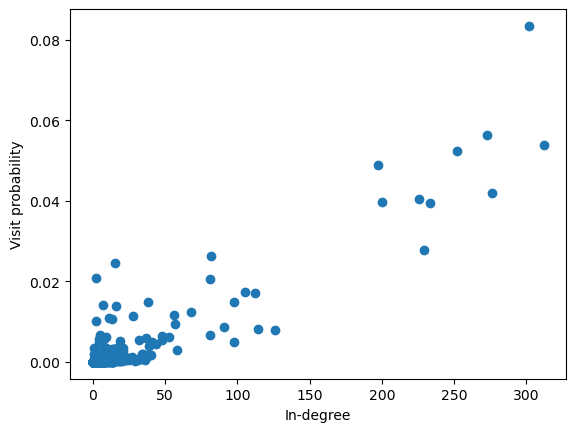

In [19]:
visit_probs_no_teleport = estimate_visit_probabilities(
    g_pr,
    num_steps=250000,
    burn_in=10000
)

indeg = np.array(g_pr.degree(mode="in"))

plt.scatter(indeg, visit_probs_no_teleport)
plt.xlabel("In-degree")
plt.ylabel("Visit probability")
plt.show()

Nodes with higher in-degree tend to have higher visit probability. This is because the random walker is more likely to arrive at nodes that have many incoming edges.

2.3b

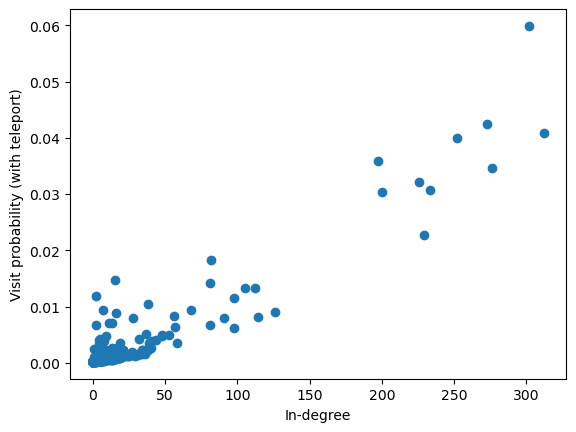

In [20]:
visit_probs_teleport = estimate_visit_probabilities(
    g_pr,
    num_steps=250000,
    burn_in=10000,
    teleport_prob=0.2
)

plt.scatter(indeg, visit_probs_teleport)
plt.xlabel("In-degree")
plt.ylabel("Visit probability (with teleport)")
plt.show()

With teleportation, the visit probability becomes less concentrated on high-degree nodes. Teleportation allows the walker to reach all nodes, reducing the dominance of hubs.

2.4a

In [21]:
baseline_pr = np.array(g_pr.pagerank(directed=True))
baseline_pr /= baseline_pr.sum()

visit_probs_ppr = estimate_visit_probabilities(
    g_pr,
    num_steps=250000,
    burn_in=10000,
    teleport_prob=0.2,
    teleport_weights=baseline_pr
)

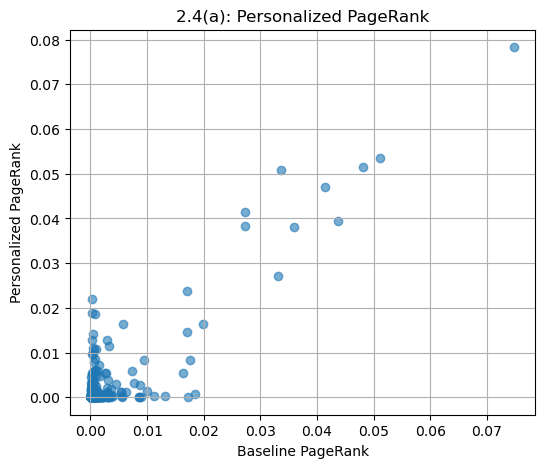

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(baseline_pr, visit_probs_ppr, alpha=0.6)
plt.xlabel("Baseline PageRank")
plt.ylabel("Personalized PageRank")
plt.title("2.4(a): Personalized PageRank")
plt.grid(True)
plt.show()

In this case, teleportation is proportional to the original PageRank. Nodes that already have high PageRank receive more teleportation, which makes their importance even higher. This creates a reinforcing effect. Compared to part 3(a), the distribution is more concentrated on high PageRank nodes, since teleportation now favors already important nodes.

2.4b

In [26]:
idx = np.argsort(baseline_pr)

mid1 = idx[len(idx)//2]
mid2 = idx[len(idx)//2 - 1]

print(mid1, mid2)

194 300


In [27]:
pref = np.zeros(g_pr.vcount())
pref[mid1] = 0.5
pref[mid2] = 0.5

In [28]:
visit_probs_two = estimate_visit_probabilities(
    g_pr,
    num_steps=250000,
    burn_in=10000,
    teleport_prob=0.2,
    teleport_weights=pref
)

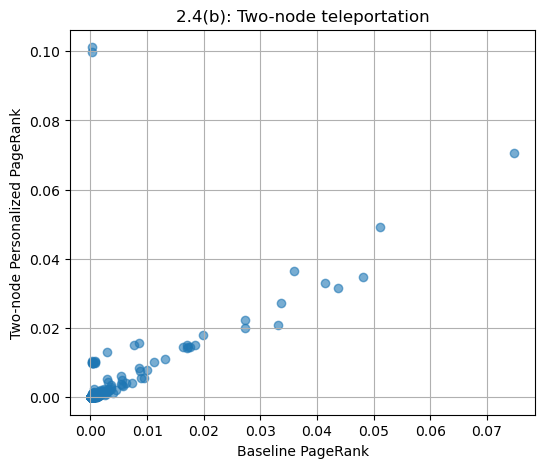

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(baseline_pr, visit_probs_two, alpha=0.6)
plt.xlabel("Baseline PageRank")
plt.ylabel("Two-node Personalized PageRank")
plt.title("2.4(b): Two-node teleportation")
plt.grid(True)
plt.show()

When teleportation is restricted to two nodes, these nodes receive much higher importance. The ranking of the network changes significantly because the random walker frequently returns to these two nodes. Compared to 2.4(a), the ranking is now heavily biased toward the two selected nodes, showing that personalized teleportation can strongly distort the PageRank distribution.

2.4c

The standard PageRank uses a uniform teleportation vector, meaning the random walker can jump to any node with equal probability.

To model a scenario where users only visit trusted pages, we can replace the uniform teleportation vector with a personalized vector q, where higher probability is assigned to trusted nodes.

The PageRank equation becomes:
π = (1−α)P^Tπ + αq

This modification allows the model to reflect user preferences and can significantly change the ranking results.